# Import libraries

In [1]:
import json
from subprocess import run
import time
import pymongo
import requests
#from pathlib import Path
from urllib.parse import unquote
from urllib.parse import urlencode

In [48]:
from datetime import datetime

In [36]:
from pprint import pprint

# Get mongoDB up and running

uncomment the cells below to get the mongo dbms daemon running outside of Jupyter

In [ ]:
#!conda install mongodb

In [ ]:
#!mkdir local_mongodb

In [ ]:
#!mongod --dbpath ./local_mongodb --logpath ./mongodb.log --fork

In [ ]:
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["mydatabase"]

In [56]:
search_collection = db['search_results']

In [57]:
#list( search_collection.find() )
#search_collection.drop()

# (Optional) Pull github personal access token from local password store

* You don't need one of these to search github, but it helps
* For ease, you can simply copy/paste your github personal access token into the variable ```github_pat``` below
* Or, if you're like me you can set up a password store on your local machine. For details, see this youtube video: [This is perhaps my favorite password manager for the terminal](https://youtu.be/FhwsfH2TpFA?si=BaY7sn87DAQGjubi)

In [ ]:
# Comment these lines out if you're not using a local password store
retval = run( ['pass', 'show', '/github/fine_grained_PAT/Coletta_Bot_001'], capture_output=True )
github_pat = str( retval.stdout, encoding="utf-8" ).strip()
if len( github_pat ) == 0:
    raise ValueError( "could not pull secret from password store" )

# Set up Github API calls

In [59]:
# GitHub API endpoint for searching repositories
api_url = "https://api.github.com/search/repositories"

# Replace this with your desired keyword
keyword = "geospatial"
#keyword = "earth-observation"
#keyword = 'remote-sensing'
#keyword = "geojson"
#keyword = 'postgis'
#keyword = 'gdal'
#keyword = 'ogc'
#keyword = 'osgeo'

# Query parameters: search for non-archived repositories with the keyword
query = f'{ keyword }+in:name,description,readme+archived:false'

headers = {
    'Accept': "application/vnd.github.v3+json",
    'Authorization': github_pat,
    "X-GitHub-Api-Version": "2022-11-28"
}

In [60]:
payload = {
    'q': query,
    #'sort': 'stars',
    'sort': 'relevance',
    'type': 'Repositories',
    'order': 'desc',
    'per_page': 100,
}

In [61]:
for i in range(1,11):
    payload['page'] = i
    print( "page", i )
    payload_str = urlencode( payload, safe=':,+' )
    r = requests.get( api_url, params=payload_str, headers=headers )
    response_headers = dict( r.headers )
    
    if 'X-RateLimit-Remaining' in response_headers and \
        int( response_headers[ 'X-RateLimit-Remaining' ] ) == 0 and \
        bool( response_headers['X-RateLimit-Reset'] ):
        block_until = datetime.fromtimestamp( int( response_headers['X-RateLimit-Reset'] ) )
        duration = (block_until - datetime.now()).total_seconds()
        print( f'Need to sleep for { duration:0.1f} seconds before resuming Github REST API calls' )
        time.sleep(duration)
        # try again
        i -= 1
        continue

    response = r.json()

    if 'status' in response:
        print( response )
        continue

    print( 'len =', len( response['items'] ), 'response total count', response['total_count'] )

    search_collection.insert_many( response['items'] )

    #time.sleep( 5 )

    if response['total_count'] < (( payload['page'] + 1 ) * payload['per_page']):
        break

page 1
len = 100 response total count 44304
page 2
len = 100 response total count 44304
page 3
len = 100 response total count 44304
page 4
len = 100 response total count 44304
page 5
len = 100 response total count 44304
page 6
len = 100 response total count 44304
page 7
len = 100 response total count 44304
page 8
len = 100 response total count 44304
page 9
len = 100 response total count 44304
page 10
len = 100 response total count 44304


# Pull relevant fields from MongoDB

In [62]:
return_val_schema = {
    '_id': 0, # don't return the mongodb id
    'name': 1,
    'owner.login': 1,
    'description': 1,
    'created_at': 1,
    'updated_at': 1,
    'pushed_at': 1,
    'stargazers_count': 1,
    'archived': 1,
    'forks_count': 1,
    'open_issues_count': 1,
    'license.name': 1,
    'topics': 1
}

In [63]:
results = search_collection.find( {}, {} )

In [64]:
results = list( results )

In [65]:
len( results )

1000

# Flatten nested objects within search results

In [66]:
def FlattenOne( key, value ):
    newkey = key + '_' + list( value.keys() )[0]
    return ( newkey, list( value.values() )[0] )

In [67]:
def FlattenDoc( d ):
    return dict( [ (k, v) if not isinstance( v, dict ) else FlattenOne( k,v ) for k,v in d.items() ] )

In [68]:
results = [ FlattenDoc( d ) for d in results ]

# Create a dataframe of all the results from Github

In [69]:
import pandas as pd

In [70]:
df = pd.DataFrame( results )

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 82 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   _id                          1000 non-null   object 
 1   id                           1000 non-null   int64  
 2   node_id                      1000 non-null   object 
 3   name                         1000 non-null   object 
 4   full_name                    1000 non-null   object 
 5   private                      1000 non-null   bool   
 6   owner_login                  1000 non-null   object 
 7   html_url                     1000 non-null   object 
 8   description                  926 non-null    object 
 9   fork                         1000 non-null   bool   
 10  url                          1000 non-null   object 
 11  forks_url                    1000 non-null   object 
 12  keys_url                     1000 non-null   object 
 13  collaborators_url  

In [128]:
df.sort_values( 'stargazers_count', ascending=False ).head()

,_id,id,node_id,name,full_name,private,owner_login,html_url,description,fork,...,is_template,web_commit_signoff_required,topics,visibility,forks,open_issues,watchers,default_branch,score,license
363,66db51c1dfc73e7a62411231,507775,MDEwOlJlcG9zaXRvcnk1MDc3NzU=,elasticsearch,elastic/elasticsearch,False,elastic,https://github.com/elastic/elasticsearch,"Free and Open, Distributed, RESTful Search Engine",False,...,False,False,"[elasticsearch, java, search-engine]",public,24563,4548,69414,main,1.0,NaN
63,66db51acdfc73e7a62411105,39464018,MDEwOlJlcG9zaXRvcnkzOTQ2NDAxOA==,superset,apache/superset,False,apache,https://github.com/apache/superset,Apache Superset is a Data Visualization and Da...,False,...,False,False,"[analytics, apache, apache-superset, asf, bi, ...",public,13448,938,61592,master,1.0,NaN
845,66db51e4dfc73e7a62411413,21648001,MDEwOlJlcG9zaXRvcnkyMTY0ODAwMQ==,awesome-java,akullpp/awesome-java,False,akullpp,https://github.com/akullpp/awesome-java,"A curated list of awesome frameworks, librarie...",False,...,False,False,"[awesome, awesome-list]",public,7322,2,41235,master,1.0,NaN
922,66db51ebdfc73e7a62411460,107595270,MDEwOlJlcG9zaXRvcnkxMDc1OTUyNzA=,Mask_RCNN,matterport/Mask_RCNN,False,matterport,https://github.com/matterport/Mask_RCNN,Mask R-CNN for object detection and instance s...,False,...,False,False,"[instance-segmentation, keras, mask-rcnn, obje...",public,11683,2022,24516,master,1.0,NaN
170,66db51b3dfc73e7a62411170,15823460,MDEwOlJlcG9zaXRvcnkxNTgyMzQ2MA==,redisson,redisson/redisson,False,redisson,https://github.com/redisson/redisson,Redisson - Easy Redis Java client and Real-Tim...,False,...,False,False,"[cache, distributed, distributed-locks, execut...",public,5328,383,23168,master,1.0,NaN


In [74]:
df['license_key'].value_counts().head(10)

license_key
mit             283
apache-2.0      153
other           134
bsd-3-clause     46
gpl-3.0          36
cc0-1.0          26
gpl-2.0          15
bsd-2-clause     12
cc-by-4.0        11
agpl-3.0         10
Name: count, dtype: int64

In [75]:
df['owner_login'].value_counts().head(30)

owner_login
PacktPublishing       21
opengeos              20
ngageoint             19
opengeospatial        11
locationtech           8
giswqs                 8
OSGeo                  8
mapbox                 7
CesiumGS               7
pysal                  6
apache                 6
developmentseed        6
uber                   6
microsoft              6
datacarpentry          5
COGS108                5
geopython              5
Esri                   5
ncsu-geoforall-lab     5
CartoDB                5
koopjs                 4
acgeospatial           4
dlab-berkeley          4
iamtekson              4
antvis                 4
geopandas              4
darribas               3
Azure-Samples          3
Vizzuality             3
TerriaJS               3
Name: count, dtype: int64

## Visualize user-supplied keywords/tags/topics

In [76]:
topics = [ i.lower() for o in df['topics'].values for i in o ]

In [77]:
len( topics )

3786

In [78]:
from collections import Counter

In [79]:
c = Counter( topics )

In [129]:
c.most_common()[30:]

[('visualization', 15),
 ('jupyter-notebook', 14),
 ('spatial-analysis', 14),
 ('data', 14),
 ('jupyter', 13),
 ('google-earth-engine', 13),
 ('computer-vision', 13),
 ('webgl', 13),
 ('xarray', 12),
 ('sql', 12),
 ('postgresql', 12),
 ('data-analysis', 11),
 ('satellite', 11),
 ('rust', 11),
 ('geopackage', 11),
 ('rstats', 11),
 ('dataviz', 10),
 ('vector', 10),
 ('openstreetmap', 10),
 ('docker', 10),
 ('image-processing', 9),
 ('wms', 9),
 ('spatial-data', 9),
 ('h3', 9),
 ('mongodb', 9),
 ('redis', 9),
 ('geography', 9),
 ('3d', 9),
 ('nga', 9),
 ('geopython', 8),
 ('matplotlib', 8),
 ('nodejs', 8),
 ('earth-science', 8),
 ('pandas', 8),
 ('android', 8),
 ('geopackage-libraries', 8),
 ('r-package', 8),
 ('rasterio', 7),
 ('wps', 7),
 ('open-source', 7),
 ('earth-engine', 7),
 ('landsat', 7),
 ('uber', 7),
 ('pytorch', 7),
 ('geospatial-visualization', 7),
 ('metadata', 7),
 ('open-data', 7),
 ('spark', 7),
 ('analytics', 7),
 ('django', 7),
 ('hydrology', 7),
 ('leaflet', 7),
 ('a

In [81]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

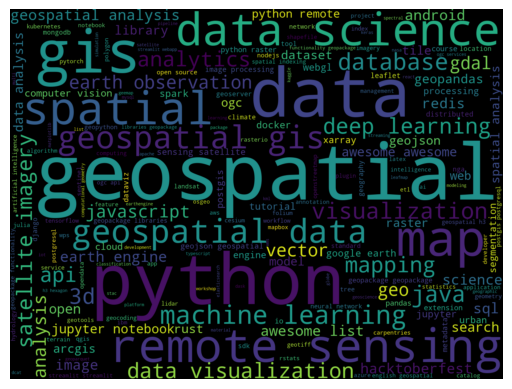

In [82]:
wordcloud = WordCloud(width=1600, height=1200, margin=0).generate( " ".join( topics ) )

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()

In [83]:
#from bson import ObjectId
#results = search_collection.find({'_id': ObjectId('66cf5198b298b376ba95e387')})

In [84]:
#cursor = search_collection.find()

#for document in cursor:
#    print(document)

# Use OpenAI API

Sign up for an account at platform.openai.com and put some money in it, like $20. Generate a project access token

## Assistants API resources
* [Assistants API Overview](https://platform.openai.com/docs/assistants/overview)
* [Assistants Quickstart](https://platform.openai.com/docs/assistants/quickstart)
* [Assistants API reference](https://platform.openai.com/docs/api-reference/assistants/createAssistant)
* [Assistants API Deep dive](https://platform.openai.com/docs/assistants/deep-dive/creating-assistants)

## Other relevant OpenAI documentation
* [OpenAI model pricing](https://openai.com/api/pricing/)
* [OpenAI Batch API: Firing off btches of threads asynchronously for a cheaper price](https://platform.openai.com/docs/guides/batch/getting-started)

In [85]:
retval = run( ['pass', 'show', '/openai/chatgpt/Coletta_Bot_001'], capture_output=True )

In [86]:
openai_pat = str( retval.stdout, encoding="utf-8" ).strip()

In [87]:
if len( openai_pat ) == 0:
    raise ValueError( "could not pull secret from password store" )

In [88]:
from openai import OpenAI
client = OpenAI( api_key=openai_pat )

In [89]:
instructions = """
I would like you to evaluate some open source repositories that may contain source code, documentation, planning documents,
aggregated lists of helpful resources, or other purposes purportedly related to software development.
Please evaluate them according to the specific criteria I provide here, and then output your feedback in the form
of structured json using the keys given at the start of each criterion.

1. awareness: As of your last update, do you have specific awareness of the given software package?
2. confidence: On a scale from 0 to 10, how confident are you about speaking about the given software package without making assumptions or conjectures?
3. is_geospatial_software: Is the primary purpose of the given repository to host code for a specific software project that has specific use in the geospatial, geographic information system, spatiotemporal or allied fields? If this is an awesome list or documentation related to defining a specification without the implementing source, please answer false.
4. description: describe what the software is and give an overview of major functionality, without the use of jargon like "intuitive" "user-friendly" "open-source" "community driven" "full-fledged" and "automatically".
5. problem_solved: Describe the problem it's trying to solve within its relevant domain.
6. keywords: Give up to 10 keywords that would be useful in categorizing the repo
7. commercial_comps: If the repo hosts a software project, list any commercial products that the software is comparable to, especially solutions provided by the cloud providers such as AWS, Azure and GCP
8. open_source_comps: If the repo hosts a software project, list any open source projects that the software is comparable to
"""

In [90]:
# from pydantic import BaseModel
# from pydantic.types import conint, List

# from typing import List

# class OpenSourceSoftwareEvaluationResponse( BaseModel ):
#     awareness: bool
#     confidence: conint( ge=0, le=10)
#     is_geospatial_software: bool
#     description: str
#     problem_solved: str
#     keywords: List[ str ]
#     comps: List[ str ]

# test_response = OpenSourceSoftwareEvaluationResponse(
#     llm_model_awareness_of_repo=True,
#     llm_confidence_of_response=10,
#     primary_function_of_repo_is_geospatial_software = False,
#     repo_description = "description string",
#     problem_repo_attempts_to_solve = "problem statement",
#     repo_characterization_keywords = [ 'test', "hello", "goodbye" ],
#     commercial_product_comps = ['aws bigquery',]
#  )

In [91]:
json_schema = {
  "name": "os_software_eval_response",
  "strict": False,
  "schema": {
    "type": "object",
    "properties": {
      "awareness": {
        "type": "boolean"
      },
      "confidence": {
        "type": "integer"
      },
      "is_geospatial_software": {
        "type": "boolean"
      },
      "description": {
        "type": "string"
      },
      "problem_solved": {
        "type": "string"
      },
      "keywords": {
        "type": "array",
        "items": {
          "type": "string"
        },
        "minItems": 1,
        "uniqueItems": True
      },
      "commercial_comps": {
        "type": "array",
        "items": {
          "type": "string"
        },
        "uniqueItems": True
      },
      "open_source_comps": {
        "type": "array",
        "items": {
          "type": "string"
        },
        "uniqueItems": True
      }
    },
    "additionalProperties": False,
    "required": []
  }
}

In [92]:
assistant_params = dict(
    model = "gpt-4o-mini",
    name = "Open Source Geospatial Software Evaluator",
    description = "An assistant that answers questions related to open source software and its purpose and function.",
    instructions = instructions,
    #response_format = OpenSourceSoftwareEvaluationResponse
    response_format = { "type": "json_schema", "json_schema": json_schema }
)

In [93]:
assistant = client.beta.assistants.create( **assistant_params )

In [123]:
ai_assistant_research_docs = db['research_results']

In [124]:
#ai_assistant_research_docs.drop()

In [125]:
#ai_assistant_research_docs.create_index('full_name')

In [126]:
def OpenAIAssist_One_Query( repo : pd.Series ):
    t1 = time.time()
    #print( repo )
    prompt = f'The repo "{repo['name']}" by Github owner "{repo['owner_login']}"'
    print( prompt )

    if ai_assistant_research_docs.count_documents( {'full_name': repo['full_name'] } ) > 0:
        print( f"Already queried repo {repo['full_name']}" )
        return

    #repo['name']
    thread = client.beta.threads.create()
    message = client.beta.threads.messages.create(
        thread_id=thread.id,
        role="user",
        content=prompt
    )
    try:
        run = client.beta.threads.runs.create_and_poll(
            thread_id=thread.id,
            assistant_id=assistant.id
        )                                  
        if run.status != 'completed':
            raise BadRequestError( run.status )
        # Structure of return object described in API docs:
        #https://platform.openai.com/docs/api-reference/messages/listMessages
        messages = client.beta.threads.messages.list( thread_id=thread.id )
        eval_text = messages.data[0].content[0].text.value
        evaluation = json.loads( eval_text )
    except BadRequestError as e:
        # An example:
        # BadRequestError: Error code: 400 - {'error': {'message': 'Thread thread_OGvr1yedd36bFGOyuDnkLqkB
        # already has an active run run_r8yWftutLRPquqSNp9yfXV1x.', 'type': 'invalid_request_error', 'param': None, 'code': None}}
        print( "**ERROR**" )
        print( e )
        return

    record = { **dict( repo ),  **evaluation }
    
    t2 = time.time()
    record['time'] = t2 - t1
    #print( record )
    ai_assistant_research_docs.insert_one( record )

In [127]:
df.apply( OpenAIAssist_One_Query, axis=1 )

The repo "geospatial" by Github owner "OCA"
The repo "geospatial" by Github owner "opengeos"
The repo "geospatial" by Github owner "rstudio-conf-2020"
The repo "geospatial" by Github owner "opensearch-project"
The repo "geoserver" by Github owner "geoserver"
The repo "geospatial" by Github owner "php-geospatial"
The repo "leafmap" by Github owner "opengeos"
The repo "awesome-gis" by Github owner "sshuair"
The repo "Awesome-Geospatial" by Github owner "sacridini"
The repo "gdal" by Github owner "OSGeo"
The repo "QGIS" by Github owner "qgis"
The repo "segment-geospatial" by Github owner "opengeos"
The repo "streamlit-geospatial" by Github owner "opengeos"
The repo "geemap" by Github owner "gee-community"
The repo "sedona" by Github owner "apache"
The repo "tile38" by Github owner "tidwall"
The repo "cartodb" by Github owner "CartoDB"
The repo "3d-tiles" by Github owner "CesiumGS"
The repo "python-geospatial" by Github owner "opengeos"
The repo "h3" by Github owner "uber"
The repo "torchg

0      None
1      None
2      None
3      None
4      None
       ... 
995    None
996    None
997    None
998    None
999    None
Length: 1000, dtype: object